# Deep Learning Experiment — RNN Text Generation

**Student Name:** Nishanth P  
**Roll Number:** 24BAD405  

**Experiment:** Tiny Shakespeare text preprocessing, Simple RNN next-word prediction, optimizer comparison, and text generation.

> Run cells sequentially. The dataset-loading cell uses the Hugging Face Parquet conversion of Tiny Shakespeare to avoid the deprecated dataset-script loader.

In [1]:
def whoami():
    name = "Nishanth P"
    roll_no = "24BAD405"
    print(f"Student Name : {name}")
    print(f"Roll Number  : {roll_no}")

whoami()

Student Name : Nishanth P
Roll Number  : 24BAD405


In [2]:
%pip install -q -U datasets huggingface_hub tensorflow matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
whoami()

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from datasets import load_dataset
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)

Student Name : Nishanth P
Roll Number  : 24BAD405


I0000 00:00:1787559144.963787   16283 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787559144.968294   16283 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787559145.459123   16283 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787559146.642607   16283 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow Version: 2.21.0
NumPy Version: 2.5.2


## PART A — DATASET PREPARATION

Load Tiny Shakespeare from Hugging Face, inspect samples, tokenize words, build a vocabulary, create next-word sequences, pad sequences, and prepare training/validation data.

In [4]:
whoami()

# Hugging Face Parquet conversion of Tiny Shakespeare.
# This avoids the deprecated legacy dataset-loading script.
dataset = load_dataset(
    "karpathy/tiny_shakespeare",
    revision="refs/pr/2"
)

print("\nDataset:")
print(dataset)

Student Name : Nishanth P
Roll Number  : 24BAD405


Generating test split: 100%|██████████| 1/1 [00:00<00:00, 540.16 examples/s]


Dataset:
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 1
    })
    test: Dataset({
        features: ['text'],
        num_rows: 1
    })
})


In [5]:
whoami()

print("Dataset splits:")
print(dataset)

print("\nColumns:")
for split in dataset:
    print(split, "->", dataset[split].column_names)

print("\nFirst training sample:")
print(dataset["train"][0]["text"][:1500])

Student Name : Nishanth P
Roll Number  : 24BAD405
Dataset splits:
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 1
    })
    test: Dataset({
        features: ['text'],
        num_rows: 1
    })
})

Columns:
train -> ['text']
validation -> ['text']
test -> ['text']

First training sample:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yi

In [6]:
whoami()

train_text = "\n".join(dataset["train"]["text"])
validation_text = "\n".join(dataset["validation"]["text"])
test_text = "\n".join(dataset["test"]["text"])

print("Training characters   :", len(train_text))
print("Validation characters :", len(validation_text))
print("Test characters       :", len(test_text))

Student Name : Nishanth P
Roll Number  : 24BAD405
Training characters   : 1003854
Validation characters : 55770
Test characters       : 55770


In [7]:
whoami()

train_text = train_text.lower()
validation_text = validation_text.lower()
test_text = test_text.lower()

print("Lowercase training sample:")
print(train_text[:1000])

Student Name : Nishanth P
Roll Number  : 24BAD405
Lowercase training sample:
first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor citizens, the patricians good.
what authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them let us revenge this with
our pikes, ere we become rakes: for

In [8]:
whoami()

def tokenize_text(text):
    # Word-level tokenizer with simple punctuation tokens.
    return re.findall(r"[a-zA-Z]+(?:'[a-zA-Z]+)?|[.,!?;:]", text.lower())

train_tokens = tokenize_text(train_text)
validation_tokens = tokenize_text(validation_text)
test_tokens = tokenize_text(test_text)

print("First 100 training tokens:")
print(train_tokens[:100])

print("\nTotal training tokens   :", len(train_tokens))
print("Total validation tokens :", len(validation_tokens))
print("Total test tokens       :", len(test_tokens))

Student Name : Nishanth P
Roll Number  : 24BAD405
First 100 training tokens:
['first', 'citizen', ':', 'before', 'we', 'proceed', 'any', 'further', ',', 'hear', 'me', 'speak', '.', 'all', ':', 'speak', ',', 'speak', '.', 'first', 'citizen', ':', 'you', 'are', 'all', 'resolved', 'rather', 'to', 'die', 'than', 'to', 'famish', '?', 'all', ':', 'resolved', '.', 'resolved', '.', 'first', 'citizen', ':', 'first', ',', 'you', 'know', 'caius', 'marcius', 'is', 'chief', 'enemy', 'to', 'the', 'people', '.', 'all', ':', 'we', "know't", ',', 'we', "know't", '.', 'first', 'citizen', ':', 'let', 'us', 'kill', 'him', ',', 'and', "we'll", 'have', 'corn', 'at', 'our', 'own', 'price', '.', "is't", 'a', 'verdict', '?', 'all', ':', 'no', 'more', 'talking', "on't", ';', 'let', 'it', 'be', 'done', ':', 'away', ',', 'away', '!']

Total training tokens   : 224576
Total validation tokens : 12958
Total test tokens       : 12615


In [9]:
whoami()

# Count word frequency.
word_counts = {}

for word in train_tokens:
    word_counts[word] = word_counts.get(word, 0) + 1

# Sort vocabulary by frequency.
sorted_words = sorted(
    word_counts.items(),
    key=lambda x: x[1],
    reverse=True
)

# Index 0 is reserved for padding.
word_to_index = {
    word: index + 1
    for index, (word, count) in enumerate(sorted_words)
}

index_to_word = {
    index: word
    for word, index in word_to_index.items()
}

vocab_size = len(word_to_index) + 1

print("Vocabulary size:", vocab_size)

print("\nFirst 30 vocabulary entries:")
for word, index in list(word_to_index.items())[:30]:
    print(f"{word:15} -> {index}")

Student Name : Nishanth P
Roll Number  : 24BAD405
Vocabulary size: 11683

First 30 vocabulary entries:
,               -> 1
:               -> 2
.               -> 3
the             -> 4
and             -> 5
to              -> 6
i               -> 7
of              -> 8
;               -> 9
my              -> 10
you             -> 11
a               -> 12
that            -> 13
?               -> 14
in              -> 15
!               -> 16
is              -> 17
not             -> 18
for             -> 19
with            -> 20
it              -> 21
me              -> 22
your            -> 23
be              -> 24
his             -> 25
he              -> 26
this            -> 27
but             -> 28
have            -> 29
as              -> 30


In [10]:
whoami()

train_encoded = [
    word_to_index[word]
    for word in train_tokens
    if word in word_to_index
]

validation_encoded = [
    word_to_index[word]
    for word in validation_tokens
    if word in word_to_index
]

test_encoded = [
    word_to_index[word]
    for word in test_tokens
    if word in word_to_index
]

print("Encoded training tokens   :", len(train_encoded))
print("Encoded validation tokens :", len(validation_encoded))
print("Encoded test tokens       :", len(test_encoded))

print("\nFirst 30 encoded training tokens:")
print(train_encoded[:30])

Student Name : Nishanth P
Roll Number  : 24BAD405
Encoded training tokens   : 224576
Encoded validation tokens : 12461
Encoded test tokens       : 11980

First 30 encoded training tokens:
[93, 253, 2, 148, 40, 968, 150, 616, 1, 133, 22, 112, 3, 41, 2, 112, 1, 112, 3, 93, 253, 2, 11, 47, 41, 1236, 354, 6, 198, 71]


In [11]:
whoami()

SEQUENCE_LENGTH = 10

def create_sequences(encoded_tokens, sequence_length):
    X = []
    y = []

    for i in range(sequence_length, len(encoded_tokens)):
        X.append(encoded_tokens[i-sequence_length:i])
        y.append(encoded_tokens[i])

    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32)

X_train_full, y_train_full = create_sequences(
    train_encoded,
    SEQUENCE_LENGTH
)

X_val_full, y_val_full = create_sequences(
    validation_encoded,
    SEQUENCE_LENGTH
)

print("Training input shape :", X_train_full.shape)
print("Training target shape:", y_train_full.shape)

print("\nValidation input shape :", X_val_full.shape)
print("Validation target shape:", y_val_full.shape)

Student Name : Nishanth P
Roll Number  : 24BAD405
Training input shape : (224566, 10)
Training target shape: (224566,)

Validation input shape : (12451, 10)
Validation target shape: (12451,)


In [12]:
whoami()

X_train = pad_sequences(
    X_train_full,
    maxlen=SEQUENCE_LENGTH,
    padding="pre",
    truncating="pre"
)

X_val = pad_sequences(
    X_val_full,
    maxlen=SEQUENCE_LENGTH,
    padding="pre",
    truncating="pre"
)

print("Padded training shape   :", X_train.shape)
print("Padded validation shape :", X_val.shape)

print("\nExample padded sequence:")
print(X_train[0])

Student Name : Nishanth P
Roll Number  : 24BAD405
Padded training shape   : (224566, 10)
Padded validation shape : (12451, 10)

Example padded sequence:
[ 93 253   2 148  40 968 150 616   1 133]


In [13]:
whoami()

# The Tiny Shakespeare dataset already provides separate
# training and validation splits.
print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining input shape   :", X_train.shape)
print("Training target shape  :", y_train_full.shape)
print("Validation input shape :", X_val.shape)
print("Validation target shape:", y_val_full.shape)

Student Name : Nishanth P
Roll Number  : 24BAD405
Training samples  : 224566
Validation samples: 12451

Training input shape   : (224566, 10)
Training target shape  : (224566,)
Validation input shape : (12451, 10)
Validation target shape: (12451,)


In [14]:
whoami()

sample_sequence = X_train[0]

decoded_words = [
    index_to_word.get(index, "<UNK>")
    for index in sample_sequence
    if index != 0
]

target_word = index_to_word.get(y_train_full[0], "<UNK>")

print("Input sequence:")
print(" ".join(decoded_words))

print("\nTarget next word:")
print(target_word)

Student Name : Nishanth P
Roll Number  : 24BAD405
Input sequence:
first citizen : before we proceed any further , hear

Target next word:
me


## PART B — IMPLEMENTING THE RNN MODEL

Architecture:

**Input → Embedding → SimpleRNN → Dense + Softmax → Next Word**

The target is an integer word index, so `sparse_categorical_crossentropy` is used instead of one-hot encoding.

In [15]:
whoami()

EMBEDDING_DIM = 64
RNN_UNITS = 128

def create_rnn_model(optimizer="adam"):
    model = Sequential([
        Input(shape=(SEQUENCE_LENGTH,)),
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM
        ),
        SimpleRNN(RNN_UNITS),
        Dense(vocab_size, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = create_rnn_model("adam")

print("RNN model created and compiled successfully.")

Student Name : Nishanth P
Roll Number  : 24BAD405
RNN model created and compiled successfully.


E0000 00:00:1787559175.428415   16283 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787559175.446196   16283 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [16]:
whoami()

model.summary()

Student Name : Nishanth P
Roll Number  : 24BAD405


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10, 64)         │       747,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 11683)          │     1,507,107 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,279,523 (8.70 MB)

 Trainable params: 2,279,523 (8.70 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
whoami()

print("MODEL ARCHITECTURE")
print("=" * 60)

for layer in model.layers:
    print(
        f"{layer.name:20} | "
        f"{layer.__class__.__name__:15} | "
        f"{layer.output.shape}"
    )

Student Name : Nishanth P
Roll Number  : 24BAD405
MODEL ARCHITECTURE
embedding            | Embedding       | (None, 10, 64)
simple_rnn           | SimpleRNN       | (None, 128)
dense                | Dense           | (None, 11683)


## PART C — COMPARISON OF OPTIMIZATION ALGORITHMS

The experiment compares **Adam** and **RMSprop** using the same architecture, training data, validation data, number of epochs, and batch size.

In [18]:
whoami()

# Limit the number of examples so the experiment runs reasonably
# on a student laptop while retaining the required workflow.
MAX_TRAIN_SAMPLES = min(30000, len(X_train))
MAX_VAL_SAMPLES = min(5000, len(X_val))

X_train_model = X_train[:MAX_TRAIN_SAMPLES]
y_train_model = y_train_full[:MAX_TRAIN_SAMPLES]

X_val_model = X_val[:MAX_VAL_SAMPLES]
y_val_model = y_val_full[:MAX_VAL_SAMPLES]

print("Training samples used  :", len(X_train_model))
print("Validation samples used:", len(X_val_model))

Student Name : Nishanth P
Roll Number  : 24BAD405
Training samples used  : 30000
Validation samples used: 5000


In [19]:
whoami()

EPOCHS = 10
BATCH_SIZE = 128

tf.random.set_seed(42)
np.random.seed(42)

adam_model = create_rnn_model("adam")

adam_history = adam_model.fit(
    X_train_model,
    y_train_model,
    validation_data=(X_val_model, y_val_model),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Student Name : Nishanth P
Roll Number  : 24BAD405
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.0729 - loss: 6.5732 - val_accuracy: 0.0928 - val_loss: 6.4829
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.0858 - loss: 5.9178 - val_accuracy: 0.0870 - val_loss: 6.4343
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.1240 - loss: 5.5489 - val_accuracy: 0.1058 - val_loss: 6.4379
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.1381 - loss: 5.2956 - val_accuracy: 0.1038 - val_loss: 6.4767
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.1432 - loss: 5.1174 - val_accuracy: 0.1038 - val_loss: 6.4977
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.1495 - loss: 4.9605 - val_accuracy: 0.1048 - val_loss: 6.5331
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.1569 - loss: 4.8089 - val_accuracy: 0.1066 - val_loss: 6.5576
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms

In [20]:
whoami()

adam_train_loss = adam_history.history["loss"][-1]
adam_val_loss = adam_history.history["val_loss"][-1]
adam_train_accuracy = adam_history.history["accuracy"][-1]
adam_val_accuracy = adam_history.history["val_accuracy"][-1]

print("ADAM RESULTS")
print("=" * 40)
print(f"Training Loss       : {adam_train_loss:.4f}")
print(f"Validation Loss     : {adam_val_loss:.4f}")
print(f"Training Accuracy   : {adam_train_accuracy:.4f}")
print(f"Validation Accuracy : {adam_val_accuracy:.4f}")

Student Name : Nishanth P
Roll Number  : 24BAD405
ADAM RESULTS
Training Loss       : 4.4488
Validation Loss     : 6.6433
Training Accuracy   : 0.1766
Validation Accuracy : 0.1062


Student Name : Nishanth P
Roll Number  : 24BAD405


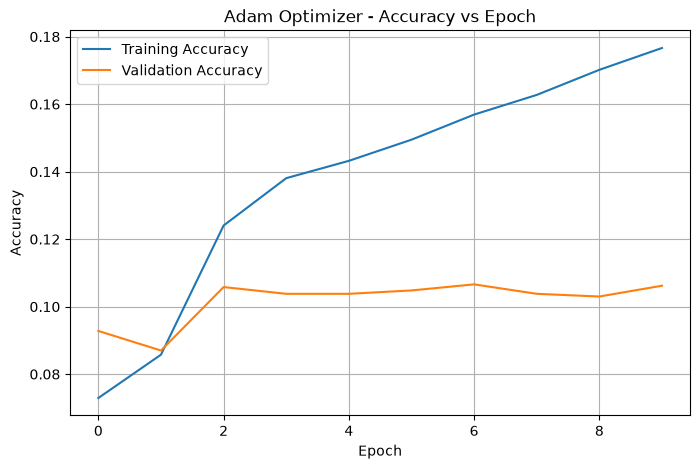

In [21]:
whoami()

plt.figure(figsize=(8, 5))
plt.plot(adam_history.history["accuracy"], label="Training Accuracy")
plt.plot(adam_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Adam Optimizer - Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Student Name : Nishanth P
Roll Number  : 24BAD405


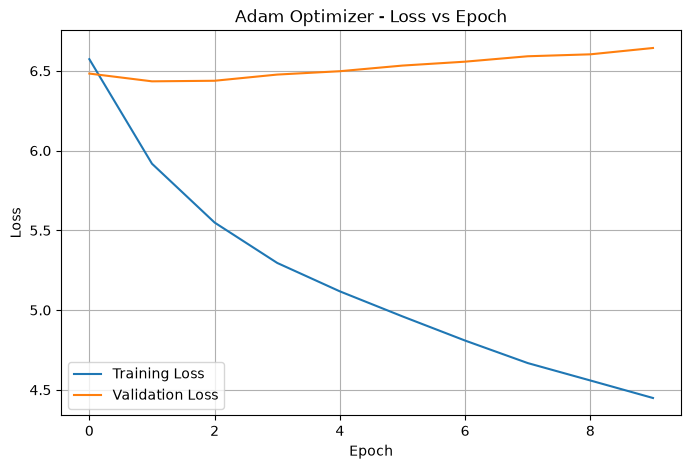

In [22]:
whoami()

plt.figure(figsize=(8, 5))
plt.plot(adam_history.history["loss"], label="Training Loss")
plt.plot(adam_history.history["val_loss"], label="Validation Loss")
plt.title("Adam Optimizer - Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
whoami()

tf.random.set_seed(42)
np.random.seed(42)

rmsprop_model = create_rnn_model("rmsprop")

rmsprop_history = rmsprop_model.fit(
    X_train_model,
    y_train_model,
    validation_data=(X_val_model, y_val_model),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Student Name : Nishanth P
Roll Number  : 24BAD405
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.0736 - loss: 6.5342 - val_accuracy: 0.0928 - val_loss: 6.3751
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.0744 - loss: 6.1954 - val_accuracy: 0.0928 - val_loss: 6.3744
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.0744 - loss: 6.1898 - val_accuracy: 0.0928 - val_loss: 6.3744
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.0744 - loss: 6.1890 - val_accuracy: 0.0928 - val_loss: 6.3744
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.0744 - loss: 6.1889 - val_accuracy: 0.0928 - val_loss: 6.3744
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.0744 - loss: 6.1889 - val_accuracy: 0.0928 - val_loss: 6.3744
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.0744 - loss: 6.1889 - val_accuracy: 0.0928 - val_loss: 6.3744
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms

In [24]:
whoami()

rms_train_loss = rmsprop_history.history["loss"][-1]
rms_val_loss = rmsprop_history.history["val_loss"][-1]
rms_train_accuracy = rmsprop_history.history["accuracy"][-1]
rms_val_accuracy = rmsprop_history.history["val_accuracy"][-1]

print("RMSPROP RESULTS")
print("=" * 40)
print(f"Training Loss       : {rms_train_loss:.4f}")
print(f"Validation Loss     : {rms_val_loss:.4f}")
print(f"Training Accuracy   : {rms_train_accuracy:.4f}")
print(f"Validation Accuracy : {rms_val_accuracy:.4f}")

Student Name : Nishanth P
Roll Number  : 24BAD405
RMSPROP RESULTS
Training Loss       : 6.1045
Validation Loss     : 6.2731
Training Accuracy   : 0.0866
Validation Accuracy : 0.1020


In [25]:
whoami()

comparison = pd.DataFrame({
    "Optimizer": ["Adam", "RMSprop"],
    "Training Accuracy": [adam_train_accuracy, rms_train_accuracy],
    "Validation Accuracy": [adam_val_accuracy, rms_val_accuracy],
    "Training Loss": [adam_train_loss, rms_train_loss],
    "Validation Loss": [adam_val_loss, rms_val_loss]
})

print(comparison.to_string(index=False))

Student Name : Nishanth P
Roll Number  : 24BAD405
Optimizer  Training Accuracy  Validation Accuracy  Training Loss  Validation Loss
     Adam           0.176633               0.1062       4.448839         6.643293
  RMSprop           0.086633               0.1020       6.104493         6.273083


Student Name : Nishanth P
Roll Number  : 24BAD405


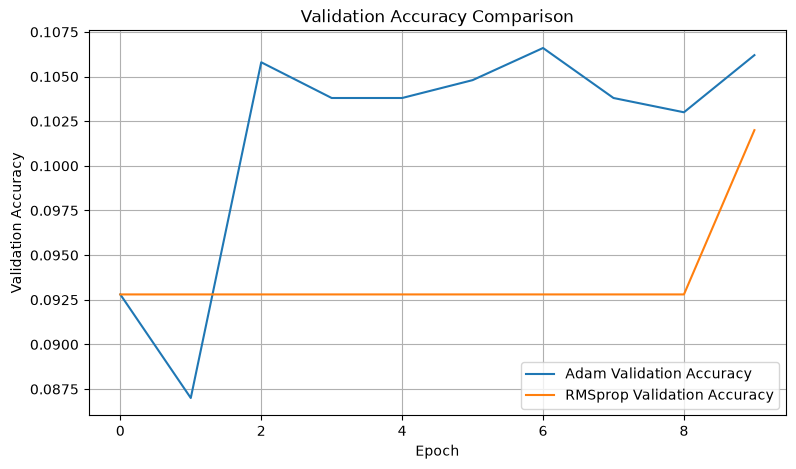

In [26]:
whoami()

plt.figure(figsize=(9, 5))

plt.plot(
    adam_history.history["val_accuracy"],
    label="Adam Validation Accuracy"
)

plt.plot(
    rmsprop_history.history["val_accuracy"],
    label="RMSprop Validation Accuracy"
)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Student Name : Nishanth P
Roll Number  : 24BAD405


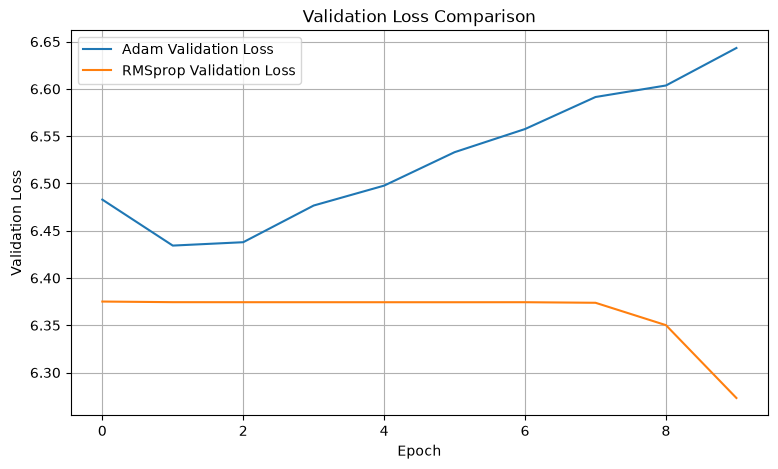

In [27]:
whoami()

plt.figure(figsize=(9, 5))

plt.plot(
    adam_history.history["val_loss"],
    label="Adam Validation Loss"
)

plt.plot(
    rmsprop_history.history["val_loss"],
    label="RMSprop Validation Loss"
)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
whoami()

if adam_val_accuracy >= rms_val_accuracy:
    best_model = adam_model
    best_optimizer = "Adam"
    best_val_accuracy = adam_val_accuracy
else:
    best_model = rmsprop_model
    best_optimizer = "RMSprop"
    best_val_accuracy = rms_val_accuracy

print("Best Optimizer:", best_optimizer)
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")

Student Name : Nishanth P
Roll Number  : 24BAD405
Best Optimizer: Adam
Best Validation Accuracy: 0.1062


## PART D — TEXT GENERATION

The trained RNN repeatedly predicts one word at a time. The predicted word is appended to the sequence and used to predict the following word.

In [29]:
whoami()

def predict_next_word(model, seed_text):
    tokens = tokenize_text(seed_text)

    encoded = [
        word_to_index.get(word, 0)
        for word in tokens
    ]

    encoded = encoded[-SEQUENCE_LENGTH:]

    padded = pad_sequences(
        [encoded],
        maxlen=SEQUENCE_LENGTH,
        padding="pre"
    )

    predictions = model.predict(padded, verbose=0)[0]

    # Avoid selecting padding as the predicted word.
    predictions[0] = 0.0

    predicted_index = int(np.argmax(predictions))

    return index_to_word.get(predicted_index, "")

def generate_text(model, seed_text, num_words=20):
    generated_text = seed_text.lower()

    for _ in range(num_words):
        next_word = predict_next_word(model, generated_text)

        if not next_word:
            break

        generated_text += " " + next_word

    return generated_text

print("Text generation functions created successfully.")

Student Name : Nishanth P
Roll Number  : 24BAD405
Text generation functions created successfully.


In [30]:
whoami()

seed = "to be or not to be"

generated = generate_text(
    best_model,
    seed,
    num_words=20
)

print("Seed:")
print(seed)

print("\nGenerated Text:")
print(generated)

Student Name : Nishanth P
Roll Number  : 24BAD405
Seed:
to be or not to be

Generated Text:
to be or not to be a country , and you shall be a voices . menenius : i have not to the people , and


In [31]:
whoami()

seed_inputs = [
    "the king",
    "my lord",
    "to be or not",
    "what is this",
    "fair prince"
]

for i, seed in enumerate(seed_inputs, start=1):
    generated = generate_text(
        best_model,
        seed,
        num_words=20
    )

    print(f"\nSample {i}")
    print("-" * 60)
    print("Seed     :", seed)
    print("Generated:", generated)

Student Name : Nishanth P
Roll Number  : 24BAD405

Sample 1
------------------------------------------------------------
Seed     : the king
Generated: the king , and you , i am , and that the gods , i have been a power of the people

Sample 2
------------------------------------------------------------
Seed     : my lord
Generated: my lord of the people , and you , sir , i am , and i am , and a power of

Sample 3
------------------------------------------------------------
Seed     : to be or not
Generated: to be or not than the people , and you , sir , i have been to the people , and you , sir

Sample 4
------------------------------------------------------------
Seed     : what is this
Generated: what is this , and that he have been a power of the people , and you , sir , i am ,

Sample 5
------------------------------------------------------------
Seed     : fair prince
Generated: fair prince , and that he have been a power of the people , and you , sir , i am ,


In [32]:
whoami()

samples = []

for seed in seed_inputs:
    generated = generate_text(
        best_model,
        seed,
        num_words=15
    )

    samples.append({
        "Seed": seed,
        "Generated Text": generated
    })

generation_df = pd.DataFrame(samples)

print(generation_df.to_string(index=False))

Student Name : Nishanth P
Roll Number  : 24BAD405
        Seed                                                           Generated Text
    the king              the king , and you , i am , and that the gods , i have been
     my lord                  my lord of the people , and you , sir , i am , and i am
to be or not to be or not than the people , and you , sir , i have been to the people
what is this   what is this , and that he have been a power of the people , and you ,
 fair prince    fair prince , and that he have been a power of the people , and you ,


## Observations

- The RNN learns sequential word patterns from the Tiny Shakespeare corpus.
- Training and validation accuracy/loss indicate how well the model learns and generalizes.
- Adam and RMSprop can converge at different rates because their parameter-update mechanisms differ.
- Generated text is expected to contain Shakespeare-like vocabulary and local word patterns, but a small SimpleRNN trained for a limited number of epochs is not expected to produce fully coherent long-form language.
- Text generation quality depends strongly on vocabulary size, sequence length, training data, model capacity, optimizer, and number of epochs.

In [33]:
whoami()

print("=" * 70)
print("RNN TEXT GENERATION EXPERIMENT - FINAL SUMMARY")
print("=" * 70)

print("\nStudent Name :", "Nishanth P")
print("Roll Number  :", "24BAD405")

print("\nDataset:")
print("Tiny Shakespeare - Hugging Face")

print("\nModel:")
print("Embedding -> SimpleRNN -> Dense(Softmax)")

print("\nOptimizers Compared:")
print("1. Adam")
print("2. RMSprop")

print("\nBest Optimizer:", best_optimizer)
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")

print("\nExpected Outcome:")
print(
    "The RNN learned sequential information from the Tiny Shakespeare "
    "dataset and generated text using repeated next-word prediction."
)

Student Name : Nishanth P
Roll Number  : 24BAD405
RNN TEXT GENERATION EXPERIMENT - FINAL SUMMARY

Student Name : Nishanth P
Roll Number  : 24BAD405

Dataset:
Tiny Shakespeare - Hugging Face

Model:
Embedding -> SimpleRNN -> Dense(Softmax)

Optimizers Compared:
1. Adam
2. RMSprop

Best Optimizer: Adam
Best Validation Accuracy: 0.1062

Expected Outcome:
The RNN learned sequential information from the Tiny Shakespeare dataset and generated text using repeated next-word prediction.


In [ ]:
whoami()

MODEL_PATH = "EX05-24BAD405.keras"

best_model.save(MODEL_PATH)

print("Model saved successfully:")
print(MODEL_PATH)

Student Name : Nishanth P
Roll Number  : 24BAD405
Model saved successfully:
tiny_shakespeare_rnn.keras
